
<a id="summary"></a>

## Notebook 2 — Transactions EDA & monthly aggregates (`transactions_raw`)

**v2.** This notebook builds **`df_tx`** at **transaction month** grain (completed transactions only), runs **calendar-time EDA**, and answers roadmap questions **Q2–Q5** with **M3 + M6** cohort KPIs.

### How this notebook is organized

**Jump to parts:** [Part 1 — data loading & joins](#part-1) · [Part 2 — monthly aggregates & calendar-time EDA](#part-2) · [Part 3 — cohort analysis](#part-3)

**Part 1 — data loading & joins**

1. [Load `customers_raw` and `transactions_raw`](#q1)
2. [Join transactions to customer attributes](#q2)
3. [Transaction month buckets](#q3)

**Part 2 — monthly aggregates & calendar-time EDA**

4. [Transactions per month](#Transactions-per-month)
5. [Total amount per month](#Total-amount-per-month)
6. [Unique users over time](#Unique-users-over-time)
7. [Total amount per channel](#Total-amount-per-channel)

**Part 3 — cohort analysis (M3 + M6 retention)**

8. [Which acquisition month produces the most retained customers?](#bq2)
9. [At what month do most customers disengage?](#bq3)
10. [Are recent cohorts healthier than older ones?](#bq4)
11. [Which acquisition channel brings the highest quality customers?](#bq5)

---

### Objectives

- **Achieved:** Build **`df_tx`** joined to customer attributes (**acquisition channel**, **segment**, **registration date**), using **completed** transactions only.
- **Achieved:** Answer **Q2–Q5** with **M3 + M6** cohort KPIs, a **tenure retention curve (M0..M6)**, and **channel-quality ranking** (M6-first).
- **Deferred:** RFM, LTV, segment behavioral profiles, and predictive churn (later notebooks).

### Business Questions (from the project roadmap)

2. Which acquisition month produces the most retained customers?
3. At what month do most customers disengage?
4. Are recent cohorts healthier than older ones?
5. Which acquisition channel brings the highest quality customers?

### Expected output

- `df_tx` joined dataset (transactions + customer attributes, transaction month).
- Monthly counts / amount / MAU / channel mix for calendar-time EDA.
- Cohort outputs (overall + by `acquisition_channel`):
  - **M3 + M6 active rates**
  - **Strict streak (M0..M3, M0..M6)**
  - **Tenure retention curve (M0..M6) + drop-off window**
  - Rankings for best cohort months (quality vs volume) and best acquisition channels (M6-first).


In [2]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — Data loading & joins

**Goal:** pull **`customers_raw`** and **`transactions_raw`** (completed only) from Supabase, merge them into **`df_tx`**, and construct **`transaction_month`** for monthly aggregates.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw` and `transactions_raw` from Supabase

[↑ Back to summary](#summary)


In [3]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT *\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

display(df_customers.head())
display(df_transactions.head())
print("df_customers:", df_customers.shape)
print("df_transactions (completed):", df_transactions.shape)


,customer_id,acquisition_channel,acquisition_cost,registration_date,true_segment
0,0b8f3bda-d929-4111-abd9-992ac76066a9,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,f96dacb9-92bb-4094-977c-0de351bebff0,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,137009b3-c01b-4cb1-9b73-6096c094ea87,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,4ad24923-433d-4cbb-a335-3603a07f764c,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed


df_customers: (8000, 5)
df_transactions (completed): (2031570, 8)



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`** for cohort and channel analyses.

[↑ Back to summary](#summary)


In [4]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")

In [5]:
df_tx.head()

,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,acquisition_channel,acquisition_cost,registration_date,true_segment
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active



<a id="q3"></a>

### 3. Transaction month buckets

We normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps, then ensure **`amount`** is numeric. This grain powers monthly EDA and cohort eligibility.

[↑ Back to summary](#summary)


In [6]:

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

# Drop the trailing calendar month if we don't yet have enough intra-month coverage.
# Rule: keep the latest month only if `transaction_datetime` includes activity on
# at least 20 distinct calendar days within that month (days 1–20+).
MIN_DISTINCT_DAYS_IN_LATEST_MONTH = 20

_tx_dt_guard = df_tx["transaction_datetime"]
if isinstance(_tx_dt_guard.dtype, pd.DatetimeTZDtype):
    _tx_dt_guard = _tx_dt_guard.dt.tz_convert("UTC").dt.tz_localize(None)

last_month_period = _tx_dt_guard.dt.to_period("M").max()
last_month_mask = _tx_dt_guard.dt.to_period("M") == last_month_period

distinct_days = _tx_dt_guard.loc[last_month_mask].dt.day.nunique()

days_in_month = last_month_period.days_in_month if pd.notna(last_month_period) else None
threshold = min(MIN_DISTINCT_DAYS_IN_LATEST_MONTH, days_in_month) if days_in_month is not None else MIN_DISTINCT_DAYS_IN_LATEST_MONTH

if pd.notna(last_month_period) and distinct_days < threshold:
    print(
        f"Dropping latest month {last_month_period} from df_tx: "
        f"only {distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )
    df_tx = df_tx.loc[~last_month_mask].copy()
else:
    print(
        f"Keeping latest month {last_month_period}: "
        f"{distinct_days} distinct day(s) observed (threshold={threshold} of {days_in_month} days in month)."
    )

# Keep derived month columns consistent after potential row drops
_tx_dt2 = df_tx["transaction_datetime"]
if isinstance(_tx_dt2.dtype, pd.DatetimeTZDtype):
    _tx_dt2 = _tx_dt2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = _tx_dt2.dt.to_period("M").dt.to_timestamp()

_reg2 = df_tx["registration_date"]
if isinstance(_reg2.dtype, pd.DatetimeTZDtype):
    _reg2 = _reg2.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = _reg2.dt.to_period("M").dt.to_timestamp()

print("df_tx (joined):", df_tx.shape)
display(df_tx.head())

# Latest complete calendar month observed in completed transactions
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)


Keeping latest month 2026-02: 28 distinct day(s) observed (threshold=20 of 28 days in month).
df_tx (joined): (2031570, 14)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2023-06-01,2023-06-01


latest_complete_month: 2026-02



<a id="part-2"></a>

## Part 2 — Monthly aggregates & calendar-time EDA

**Goal:** summarize **calendar-time** behavior (counts, TPV, MAU, channel mix) to contextualize cohort findings.

[↑ Back to summary](#summary)



<a id="Transactions-per-month"></a>

### 4. Transactions per month by type

[↑ Back to summary](#summary)


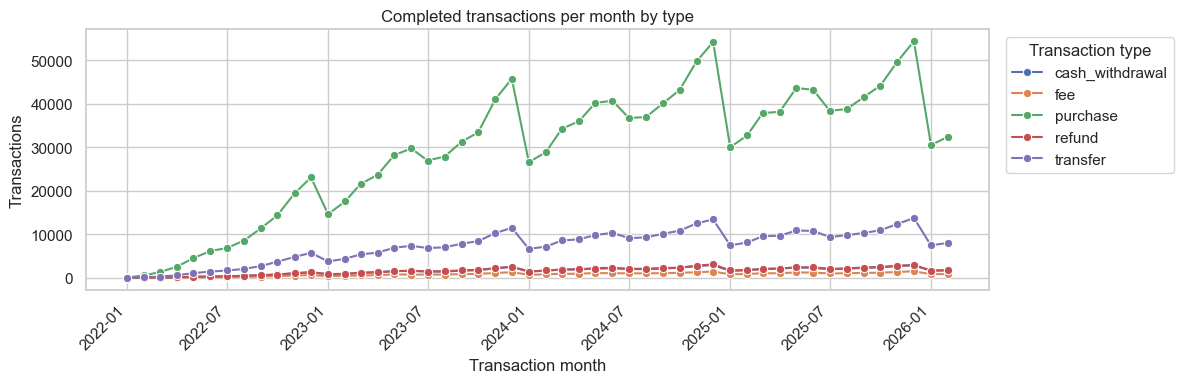

In [7]:
tx_per_month = (
    df_tx.groupby(["transaction_month", "transaction_type"], as_index=False)
    .size()
    .rename(columns={"size": "tx_count"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=tx_per_month, x="transaction_month", y="tx_count", hue="transaction_type", marker="o", ax=ax)
ax.set_title("Completed transactions per month by type")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Transactions")
ax.legend(title="Transaction type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Completed transaction volume grows from near-zero in early 2022 to ~70k transactions/month by late 205, with a clear step-up in run-rate during late 2025. The mix is heavily purchase-led, while transfers grow steadily and non-core types (fees, refunds, cash withdrawals) remain comparatively small. Seasonality plays a crucial role here.

**Business insights**
- **Revenue concentration:** Since purchase dominates volume, top-line performance is highly sensitive to purchase conversion and repeat usage; improving purchase retention likely delivers the largest revenue impact.
- **Operational planning:** The sharp late-2025 acceleration suggests capacity requirements (support, risk monitoring, payment processing) can rise quickly; forecasting should include surge scenarios rather than linear growth assumptions.
- **Product strategy:** Transfer growth indicates increasing wallet/account utility; bundling transfer-adjacent features can improve stickiness and raise monthly active engagement.
- **Risk and quality control:** As volume scales, even stable refund/fee rates can generate material absolute counts; track these as rate-based KPIs to protect margin and customer experience.



<a id="Total-amount-per-month"></a>

### 5. Total amount per month by type

[↑ Back to summary](#summary)


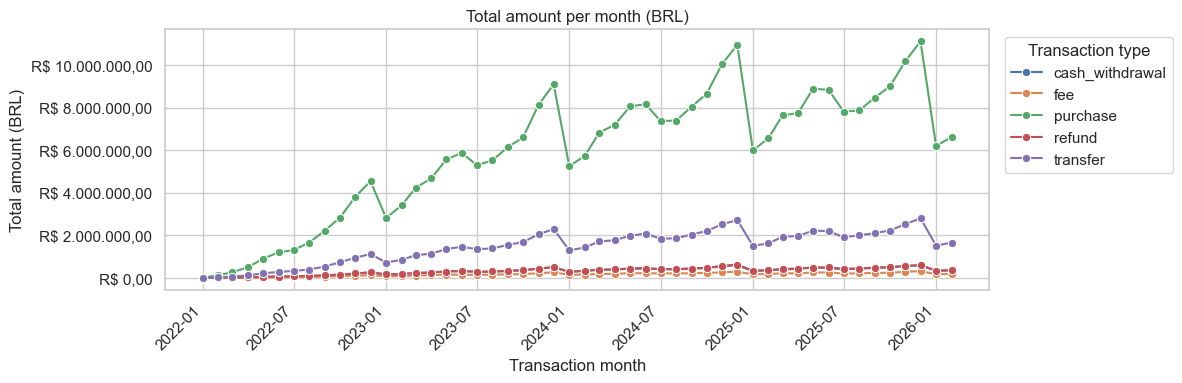

In [8]:

amount_per_month = (
    df_tx.groupby(["transaction_month", "transaction_type"], as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "total_amount"})
    .sort_values(["transaction_month", "transaction_type"])
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=amount_per_month, x="transaction_month", y="total_amount", hue="transaction_type", marker="o", ax=ax)
ax.set_title("Total amount per month (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Transaction type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Monthly TPV ramps from near-zero in early 2022 to roughly **R$15MM** by **Dec 2025**, with the steepest acceleration through **late 2025**—consistent with **scaling throughput** (more active customers and/or higher spend per active user) on **completed** transactions. The recurring sawtooth shape also suggests **seasonality**, with **holiday periods** (for example year-end shopping and travel) driving temporary peaks followed by normalization in subsequent months.



<a id="Unique-users-over-time"></a>

### 6. Unique users over time (MAU)

[↑ Back to summary](#summary)


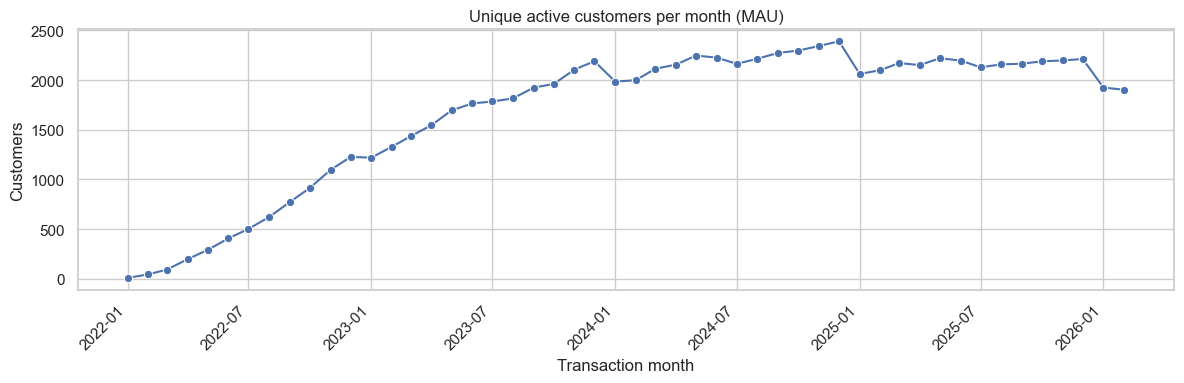

In [9]:

mau_per_month = (
    df_tx.groupby("transaction_month", as_index=False)["customer_id"]
    .nunique()
    .rename(columns={"customer_id": "mau"})
    .sort_values("transaction_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=mau_per_month, x="transaction_month", y="mau", marker="o", ax=ax)
ax.set_title("Unique active customers per month (MAU)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<span style="color:red;">MAU broadly tracks TPV, but the series appears to plateau around the ~2.1k-2.3k range after the growth phase. This is a potential red flag for momentum loss and a possible trend pivot from expansion to saturation/softening if re-acceleration does not occur in the next periods.</span>


<a id="Total-amount-per-channel"></a>

### 7. Total amount per channel over time (stacked)

[↑ Back to summary](#summary)


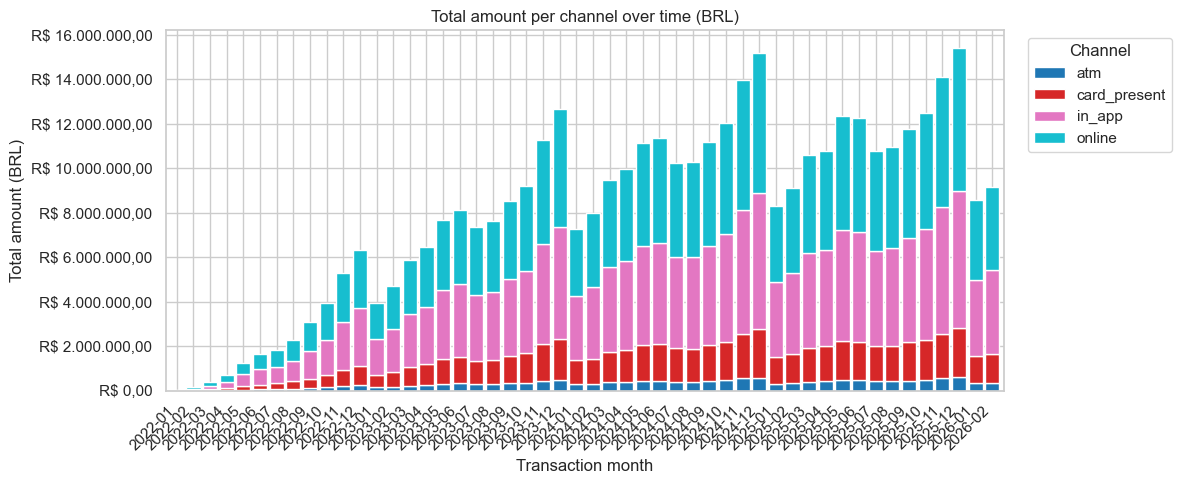

In [ ]:

amount_pivot = (
    df_tx.pivot_table(
        index="transaction_month",
        columns="channel",
        values="amount",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

# Use categorical month labels for the x-axis (avoids pandas datetime/period plotting edge cases)
amount_pivot = amount_pivot.copy()
if isinstance(amount_pivot.index, pd.PeriodIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif isinstance(amount_pivot.index, pd.DatetimeIndex):
    amount_pivot.index = amount_pivot.index.strftime("%Y-%m")
elif pd.api.types.is_period_dtype(amount_pivot.index):
    amount_pivot.index = pd.PeriodIndex(amount_pivot.index, freq="M").strftime("%Y-%m")
elif pd.api.types.is_datetime64_any_dtype(amount_pivot.index):
    amount_pivot.index = pd.to_datetime(amount_pivot.index).strftime("%Y-%m")
else:
    amount_pivot.index = amount_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
amount_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab10")
ax.set_title("Total amount per channel over time (BRL)")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Total amount (BRL)")
ax.yaxis.set_major_formatter(FuncFormatter(format_brl))
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Chart read — Total amount per channel over time (BRL, stacked):** Monthly TPV scales from a low base in early 2022 to roughly **R$15-16M** at peak by early 2026. Growth is not linear: the slope steepens in expansion phases and then normalizes, which is consistent with platform scaling rather than a single outlier month.

**Channel mix story:** **`in_app` and `online` contributes the largest share of incremental BRL** across the period and remains the core growth engine. **`card_present`**  also expand and provide diversification across payment contexts (physical and web), while **`atm`** stays comparatively small and declines in mix share over time.

**Business implication:** Prioritize reliability, fraud controls, limits strategy, and checkout UX in **`in_app`** and **`online`** (highest volume leverage). Use **`card_present`** to reduce concentration risk and support specific use cases. Keep **`atm`** optimized for niche cash-access journeys.


<a id="part-3"></a>

## Part 3 — Cohort analysis (M3 + M6 retention by registration month)

**Goal:** measure **retention quality** at **M3** and **M6** by **`cohort_month`** and **`acquisition_channel`**, using the **full customer roster** and completed transaction activity only.

[↑ Back to summary](#summary)



We compare eligible **cohort months** using **cohort size** and retention KPIs at **M3** and **M6**—each cohort is a registration (acquisition) month.

We measure retention by **cohort month**: `cohort_month` is `registration_date` truncated to month start. **M0** is the registration month; **M1..M6** are subsequent calendar months (tenure slots).

A customer is **active** in a slot if they have at least one **completed** transaction in that calendar month.

**KPIs used in this section**

- **`m3_active_rate` / `m6_active_rate`:** share of cohort members active in M3 / M6.
- **`strict_streak_m3_rate`:** share active in all of M0..M3.
- **`strict_streak_m6_rate`:** share active in all of M0..M6.

**Eligibility:** each KPI uses its own observable denominator. A customer enters M3 metrics only if `cohort_month + 3 months <= latest_complete_month`; similarly for M6 with `+ 6 months`.

**Design choices:** (1) The cohort roster comes from **`df_customers`** (all customers), not from **`df_tx`**. The latter is an inner join on completed transactions, so customers with zero completed transactions would disappear from denominators if cohorts came only from `df_tx`. (2) We detect activity by **absence vs presence**: each row in `df_tx` is a real completed transaction, so inactive months do not appear. We build a **customer × M0..M6** expected grid and **left-join** observed transaction months; no match means inactive for that month. (3) For cohort-level comparisons (retention curves, LTV), the safest core window is **Jan 2023 - Sep 2025**: pre-2023 cohorts may reflect a different acquisition motion and product maturity stage, while cohorts registered after Sep 2025 have fewer than 6 months of observable behavior (cold-start zone).


In [11]:
# Safe comparison window for cohort-level analyses
window_start = pd.Timestamp("2023-01-01")
window_end = pd.Timestamp("2026-02-28")

In [12]:

# Full cohort roster from all customers; observed active months from completed tx only
reg = df_customers["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

customers = df_customers[["customer_id", "acquisition_channel"]].copy()
customers["cohort_month"] = reg.dt.to_period("M").dt.to_timestamp()

df_tx_window = df_tx[df_tx["transaction_month"].between(window_start, window_end)].copy()

actual_active = (
    df_tx_window.groupby(["customer_id", "transaction_month"])
    .size()
    .reset_index(name="tx_count")
    .rename(columns={"transaction_month": "calendar_month"})
    .assign(has_tx=True)[["customer_id", "calendar_month", "has_tx"]]
)


In [13]:

# Parameter block for retention horizons
RETENTION_HORIZONS = [3, 6]
MAX_TENURE = max(RETENTION_HORIZONS)

# Use the selected analysis window consistently
customers_window = customers[
    customers["cohort_month"].between(window_start, window_end)
].copy()
latest_complete_month = df_tx_window["transaction_month"].max().to_period("M")

# Expected M0..M6 grid: cross-product of customers × tenure slots, left-join
# observed activity, pivot to one row per customer with m0..m6 booleans.
tenure_df = pd.DataFrame({"tenure_index": list(range(MAX_TENURE + 1))})
cust_for_grid = customers_window.copy()
cust_for_grid["_key"] = 1
tenure_df["_key"] = 1
grid = cust_for_grid.merge(tenure_df, on="_key").drop(columns="_key")

# Expected calendar month for each slot (normalized to first-of-month)
grid["calendar_month"] = grid.apply(
    lambda r: r["cohort_month"] + pd.DateOffset(months=int(r["tenure_index"])),
    axis=1,
)
grid["calendar_month"] = grid["calendar_month"].dt.to_period("M").dt.to_timestamp()

# Left join: no match means no completed transaction in that month
grid = grid.merge(actual_active, on=["customer_id", "calendar_month"], how="left")
grid["has_tx"] = grid["has_tx"].fillna(False)

pivot = grid.pivot_table(
    index=["customer_id", "cohort_month", "acquisition_channel"],
    columns="tenure_index",
    values="has_tx",
    aggfunc="max",
    fill_value=False,
).reset_index()
pivot.columns.name = None

# Normalize dynamic tenure columns to m0..m6 names
rename_map = {i: f"m{i}" for i in range(MAX_TENURE + 1)}
pivot = pivot.rename(columns=rename_map)
for i in range(MAX_TENURE + 1):
    col = f"m{i}"
    if col not in pivot.columns:
        pivot[col] = False

# Horizon-specific eligibility masks (per customer)
for h in RETENTION_HORIZONS:
    h_month = (pivot["cohort_month"] + pd.DateOffset(months=h)).dt.to_period("M")
    pivot[f"eligible_h{h}"] = h_month <= latest_complete_month

# Horizon-specific strict streak flags
pivot["strict_streak_m3"] = pivot[["m0", "m1", "m2", "m3"]].all(axis=1)
pivot["strict_streak_m6"] = pivot[[f"m{i}" for i in range(7)]].all(axis=1)

pivot.head()


,customer_id,cohort_month,acquisition_channel,m0,m1,m2,m3,m4,m5,m6,eligible_h3,eligible_h6,strict_streak_m3,strict_streak_m6
0,000c2252-f1bc-4385-8c65-2f20213e3ade,2024-06-01,partnership,False,False,True,True,True,False,False,True,True,False,False
1,002968cc-66c0-412b-8f0f-f06fb129b18e,2023-01-01,referral,True,True,False,True,True,True,True,True,True,False,False
2,002f8686-ed9a-46c2-a7ff-05eb513463d1,2025-06-01,paid_ads,False,False,True,False,True,True,False,True,True,False,False
3,003829cc-58cc-4e6b-a10d-f53d5a123ef0,2025-06-01,organic,False,False,False,False,False,True,False,True,True,False,False
4,0057dfcc-2dcd-467e-8593-d438a6be5821,2023-03-01,referral,False,True,True,True,True,True,True,True,True,False,False


In [14]:

# Cohort KPI table with horizon-specific denominators
agg_rows = []
for cohort_month, g in pivot.groupby("cohort_month"):
    row = {"cohort_month": cohort_month}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    agg_rows.append(row)

cohort_kpi = pd.DataFrame(agg_rows).sort_values("cohort_month").reset_index(drop=True)

# Q2 helper rankings: quality (rate) and volume (retained count)
q2_rank_m6_rate = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_rate", "eligible_n_h6"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]

q2_rank_m6_volume = cohort_kpi.dropna(subset=["m6_active_rate"]).sort_values(
    ["m6_active_count", "m6_active_rate"], ascending=[False, False]
)[["cohort_month", "eligible_n_h6", "m6_active_count", "m6_active_rate"]]



<a id="bq2"></a>

### Roadmap Q2 — Which acquisition month produces the most retained customers?

Reading the ranking tables below:
- **Top cohort months by M6 retention rate** (quality)
    June 2024
- **Top cohort months by retained users at M6** (volume)
    January 2023

Older windows often dominate **volume at M6** simply because more users had time to reach M6 and cohorts were larger; **quality** (M6 rate) can still peak in a more recent month (e.g. mid-2024), so “best month” depends on whether you optimize **efficiency** vs **absolute retained headcount**.

**Actionable insight:** (1) **Budget and targets:** use the **rate** leaderboard to benchmark acquisition quality and set **minimum M6-rate** guardrails by channel; use the **volume** leaderboard to understand where **scale** came from historically, not necessarily where to copy-paste spend today. (2) **Playbooks:** run a **post-mortem** on top months (mix, campaigns, product changes) and document **replicable** tactics vs one-off seasonality. (3) **Governance:** when comparing months, always read alongside **eligible N**—small denominators can inflate rates; prioritize decisions where **both** rate and N are healthy.

In [15]:
# Tables from Q2
display(cohort_kpi.tail(10))

print("Top cohort months by M6 retention rate")
display(q2_rank_m6_rate.head(8))

print("Top cohort months by retained users count at M6")
display(q2_rank_m6_volume.head(8))


,cohort_month,eligible_n_h3,m3_active_count,strict_streak_m3_count,m3_active_rate,strict_streak_m3_rate,eligible_n_h6,m6_active_count,strict_streak_m6_count,m6_active_rate,strict_streak_m6_rate
28,2025-05-01,70,40,18,0.571429,0.257143,70,33,12,0.471429,0.171429
29,2025-06-01,74,40,11,0.540541,0.148649,74,38,5,0.513514,0.067568
30,2025-07-01,89,54,17,0.606742,0.191011,89,46,12,0.516854,0.134831
31,2025-08-01,64,37,13,0.578125,0.203125,64,29,11,0.453125,0.171875
32,2025-09-01,66,42,13,0.636364,0.196970,0,0,0,NaN,NaN
33,2025-10-01,65,31,7,0.476923,0.107692,0,0,0,NaN,NaN
34,2025-11-01,56,27,11,0.482143,0.196429,0,0,0,NaN,NaN
35,2025-12-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN
36,2026-01-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN
37,2026-02-01,0,0,0,NaN,NaN,0,0,0,NaN,NaN


Top cohort months by M6 retention rate


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
17,2024-06-01,143,78,0.545455
26,2025-03-01,92,48,0.521739
15,2024-04-01,156,81,0.519231
30,2025-07-01,89,46,0.516854
5,2023-06-01,238,123,0.516807
0,2023-01-01,276,142,0.514493
29,2025-06-01,74,38,0.513514
24,2025-01-01,110,56,0.509091


Top cohort months by retained users count at M6


,cohort_month,eligible_n_h6,m6_active_count,m6_active_rate
0,2023-01-01,276,142,0.514493
2,2023-03-01,279,136,0.487455
5,2023-06-01,238,123,0.516807
1,2023-02-01,246,116,0.471545
9,2023-10-01,214,103,0.481308
3,2023-04-01,240,102,0.425000
7,2023-08-01,238,100,0.420168
11,2023-12-01,204,98,0.480392



<a id="bq3"></a>

### Roadmap Q3 — At what month do most customers disengage?

We estimate disengagement timing with a tenure retention curve (`M0..M6`) over M6-eligible customers. The largest month-to-month drop indicates where disengagement is most concentrated.


Largest disengagement window: M2 -> M3 (drop=3.48%)


,tenure_month,retention_rate,drop_from_prev
0,0,0.308478,NaN
1,1,0.603899,-0.295420
2,2,0.576079,0.027820
3,3,0.541257,0.034822
4,4,0.519871,0.021385
5,5,0.492619,0.027252
6,6,0.464610,0.028009


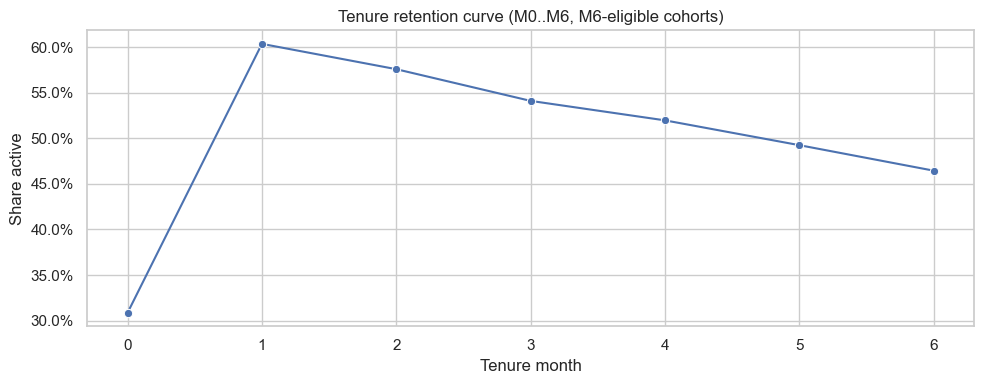

In [16]:

# Q3: tenure retention and drop-off on M6-eligible population
pivot_m6 = pivot[pivot["eligible_h6"]].copy()
retention_by_tenure = pd.DataFrame(
    {
        "tenure_month": list(range(7)),
        "retention_rate": [pivot_m6[f"m{i}"].mean() for i in range(7)],
    }
)
retention_by_tenure["drop_from_prev"] = retention_by_tenure["retention_rate"].shift(1) - retention_by_tenure[
    "retention_rate"
]

largest_drop_row = retention_by_tenure.loc[retention_by_tenure["drop_from_prev"].idxmax()]
print(
    f"Largest disengagement window: M{int(largest_drop_row['tenure_month']) - 1} -> M{int(largest_drop_row['tenure_month'])} "
    f"(drop={largest_drop_row['drop_from_prev']:.2%})"
)

display(retention_by_tenure)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=retention_by_tenure, x="tenure_month", y="retention_rate", marker="o", ax=ax)
ax.set_title("Tenure retention curve (M0..M6, M6-eligible cohorts)")
ax.set_xlabel("Tenure month")
ax.set_ylabel("Share active")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(7))
plt.tight_layout()
plt.show()


**Chart read — tenure curve (M6-eligible cohorts only):** This is a **single aggregate** lifecycle: share of customers with **at least one completed transaction** in each tenure month (M0..M6), among cohorts that are **eligible through M6** (same denominator logic as elsewhere). It does **not** compare “recent vs older” cohorts; for that, split by `cohort_month` or acquisition channel.

**Pattern:** Activity is **lowest at M0** (~low-30s % share) then **jumps sharply by M1** (toward ~60%), which is consistent with **delayed first use** (onboarding lag, setup, or first spend not landing in the registration month) rather than “weak” users at signup. After M1, the curve **declines steadily** through M6 (~mid-40s %), i.e. **ongoing churn / intermittency** within the first half-year.

The steepest **marginal drop** after M1 is **M2→M3** (~3.48 pp)—prioritize retention and habit experiments in that window.

**Actionable insight:** (1) **M0→M1:** shorten time-to-first-value with in-app prompts, KYC/funding nudges, and lifecycle email/SMS timed to days 1–7 so more users show activity in the registration month if that is strategically important. (2) **M2→M3:** treat this as the **first critical post-activation cliff**—run win-back and engagement campaigns (limits, rewards, recurring payments) for users who were active early but go quiet. (3) **Measure:** track cohort experiments on **M1 and M3 active rates** separately so onboarding fixes are not confounded with mid-tenure churn. (4) **Segment:** repeat this curve by `acquisition_channel` to avoid optimizing the average while a high-spend channel underperforms.



<a id="bq4"></a>

### Roadmap Q4 — Are recent cohorts healthier than older ones?

At the overall cohort level, we do not see a clear directional pattern in M3/M6 or strict streak rates; the series looks volatile without a sustained trend. That suggests we should not over-interpret month-to-month moves without uncertainty bands or splits. Separately, the shrinking eligible cohort size points to an acquisition/volume story that deserves its own diagnosis.

[↑ Back to summary](#summary)



<a id="bqn"></a>

### Cohort KPIs over time

We evaluate cohort quality with **M3** and **M6** active checkpoints plus strict streak variants (**M0..M3** and **M0..M6**). **M6** is the stronger quality test with this history, while **M3** remains an early leading indicator.

The second panel shows eligible denominator by horizon, so trend changes can be interpreted alongside sample support.

[↑ Back to summary](#summary)


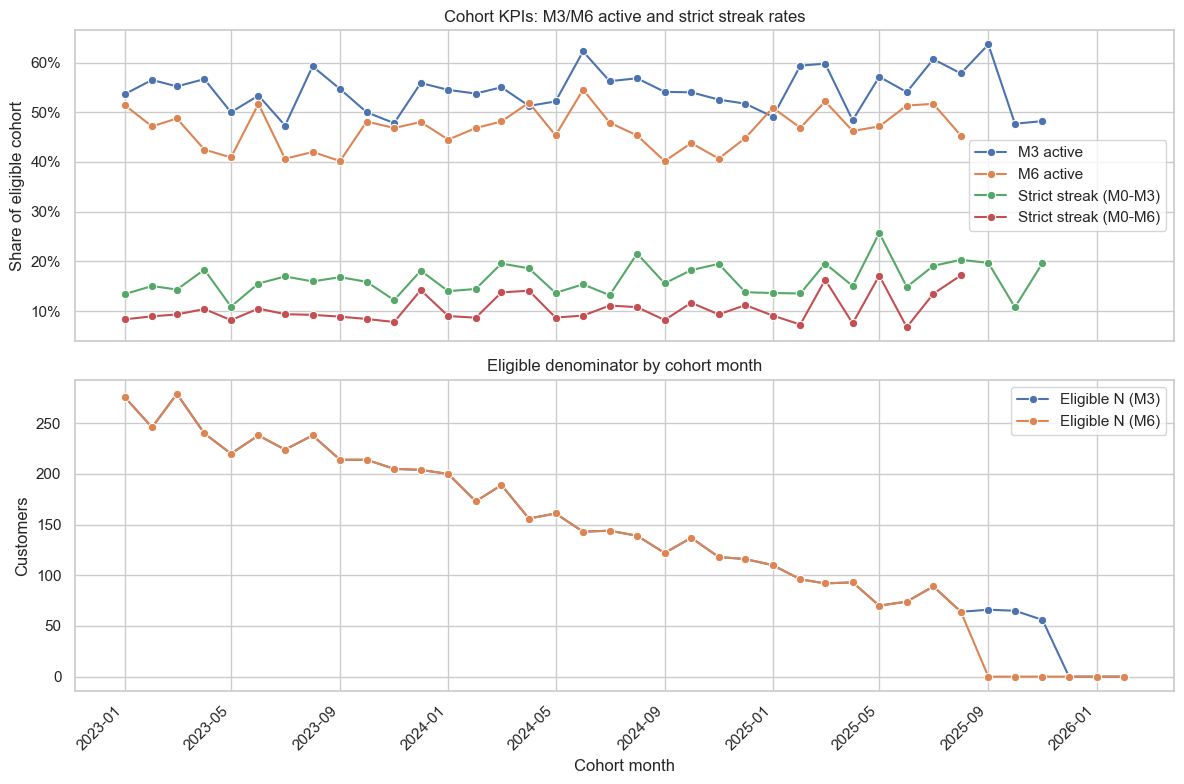

In [17]:

plot_kpi = cohort_kpi.sort_values("cohort_month").copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

kpi_long = plot_kpi.melt(
    id_vars=["cohort_month"],
    value_vars=["m3_active_rate", "m6_active_rate", "strict_streak_m3_rate", "strict_streak_m6_rate"],
    var_name="kpi",
    value_name="rate",
)
kpi_long["kpi"] = kpi_long["kpi"].map(
    {
        "m3_active_rate": "M3 active",
        "m6_active_rate": "M6 active",
        "strict_streak_m3_rate": "Strict streak (M0-M3)",
        "strict_streak_m6_rate": "Strict streak (M0-M6)",
    }
)

sns.lineplot(
    data=kpi_long,
    x="cohort_month",
    y="rate",
    hue="kpi",
    marker="o",
    ax=ax1,
)
ax1.set_title("Cohort KPIs: M3/M6 active and strict streak rates")
ax1.set_ylabel("Share of eligible cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title=None, loc="best")

sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h3",
    marker="o",
    label="Eligible N (M3)",
    ax=ax2,
)
sns.lineplot(
    data=plot_kpi,
    x="cohort_month",
    y="eligible_n_h6",
    marker="o",
    label="Eligible N (M6)",
    ax=ax2,
)
ax2.set_title("Eligible denominator by cohort month")
ax2.set_ylabel("Customers")
ax2.set_xlabel("Cohort month")
ax2.legend(title=None, loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()



<a id="bq5"></a>

#### KPIs by acquisition channel

Using the same roster and eligibility rules, we group by **`cohort_month`** and **`acquisition_channel`** and compute **M6 active rate** and **strict streak M0..M6** as primary quality metrics, with M3 as a secondary signal. The ranking table is weighted by eligible cohort size and ordered by M6 first, then M3.

[↑ Back to summary](#summary)


In [18]:

# Channel KPI table with horizon-specific denominators
ch_rows = []
for (cohort_month, channel), g in pivot.groupby(["cohort_month", "acquisition_channel"]):
    row = {"cohort_month": cohort_month, "acquisition_channel": channel}

    g3 = g[g["eligible_h3"]]
    row["eligible_n_h3"] = int(len(g3))
    row["m3_active_count"] = int(g3["m3"].sum())
    row["strict_streak_m3_count"] = int(g3["strict_streak_m3"].sum())
    row["m3_active_rate"] = row["m3_active_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    row["strict_streak_m3_rate"] = (
        row["strict_streak_m3_count"] / row["eligible_n_h3"] if row["eligible_n_h3"] else np.nan
    )

    g6 = g[g["eligible_h6"]]
    row["eligible_n_h6"] = int(len(g6))
    row["m6_active_count"] = int(g6["m6"].sum())
    row["strict_streak_m6_count"] = int(g6["strict_streak_m6"].sum())
    row["m6_active_rate"] = row["m6_active_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    row["strict_streak_m6_rate"] = (
        row["strict_streak_m6_count"] / row["eligible_n_h6"] if row["eligible_n_h6"] else np.nan
    )

    ch_rows.append(row)

channel_kpi = pd.DataFrame(ch_rows).sort_values(["cohort_month", "acquisition_channel"]).reset_index(drop=True)

# Q5 helper ranking: M6-first quality ranking by channel
channel_rank = (
    channel_kpi.dropna(subset=["m6_active_rate"])
    .groupby("acquisition_channel")
    .apply(
        lambda g: pd.Series(
            {
                "eligible_n_h6": g["eligible_n_h6"].sum(),
                "m6_active_rate_weighted": np.average(g["m6_active_rate"], weights=g["eligible_n_h6"]),
                "m3_active_rate_weighted": np.average(g["m3_active_rate"], weights=g["eligible_n_h3"]),
            }
        )
    )
    .reset_index()
    .sort_values(["m6_active_rate_weighted", "m3_active_rate_weighted"], ascending=False)
)

display(channel_kpi.tail(10))
print("Channel quality ranking (M6 primary, M3 secondary)")
display(channel_rank)


,cohort_month,acquisition_channel,eligible_n_h3,m3_active_count,strict_streak_m3_count,m3_active_rate,strict_streak_m3_rate,eligible_n_h6,m6_active_count,strict_streak_m6_count,m6_active_rate,strict_streak_m6_rate
142,2025-12-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
143,2025-12-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
144,2026-01-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
145,2026-01-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
146,2026-01-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
147,2026-01-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN
148,2026-02-01,organic,0,0,0,NaN,NaN,0,0,0,NaN,NaN
149,2026-02-01,paid_ads,0,0,0,NaN,NaN,0,0,0,NaN,NaN
150,2026-02-01,partnership,0,0,0,NaN,NaN,0,0,0,NaN,NaN
151,2026-02-01,referral,0,0,0,NaN,NaN,0,0,0,NaN,NaN


Channel quality ranking (M6 primary, M3 secondary)


,acquisition_channel,eligible_n_h6,m6_active_rate_weighted,m3_active_rate_weighted
3,referral,1242.0,0.638486,0.714976
2,partnership,1278.0,0.507042,0.566510
0,organic,1352.0,0.431953,0.515533
1,paid_ads,1412.0,0.304533,0.390227


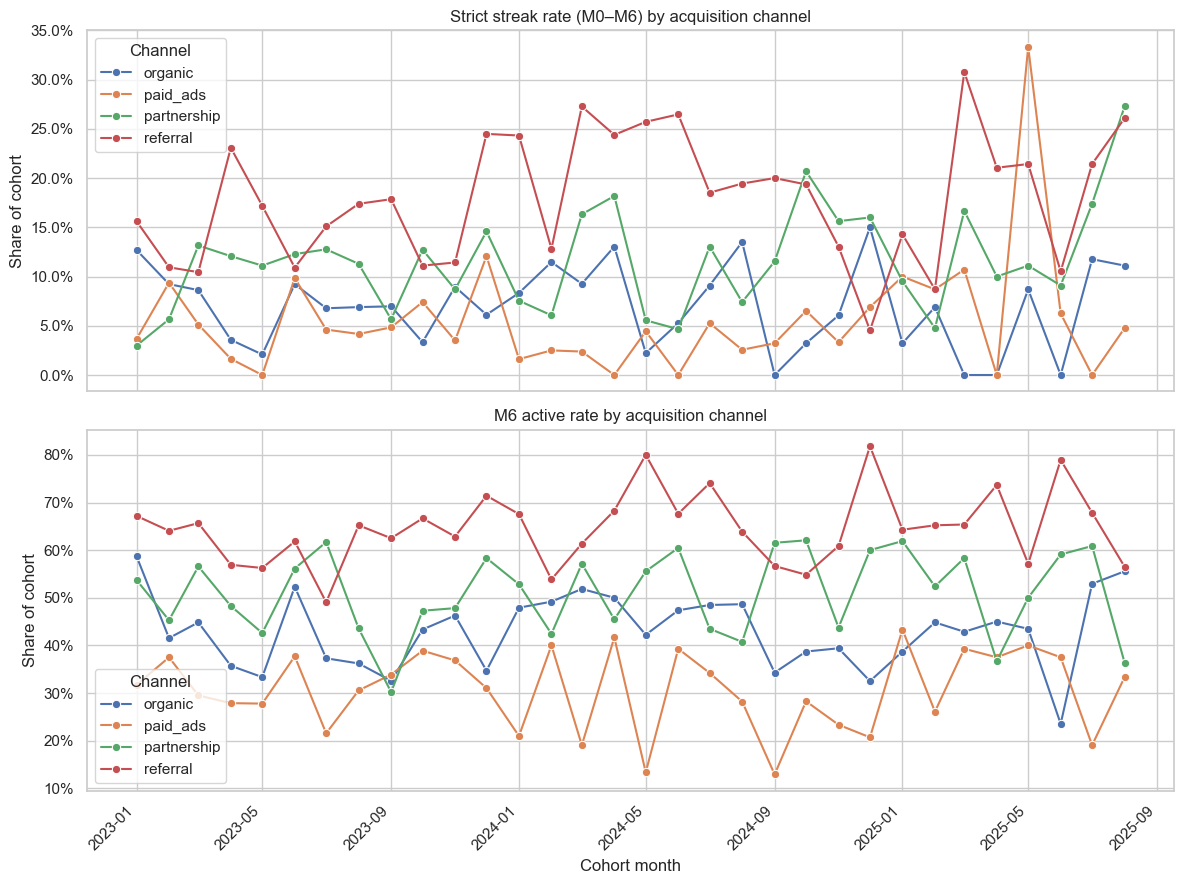

In [19]:

plot_ch = channel_kpi.sort_values(["cohort_month", "acquisition_channel"]).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="strict_streak_m6_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title("Strict streak rate (M0–M6) by acquisition channel")
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=plot_ch,
    x="cohort_month",
    y="m6_active_rate",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title("M6 active rate by acquisition channel")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


### Rolling average of channel cohort rates (reduces month-to-month noise)

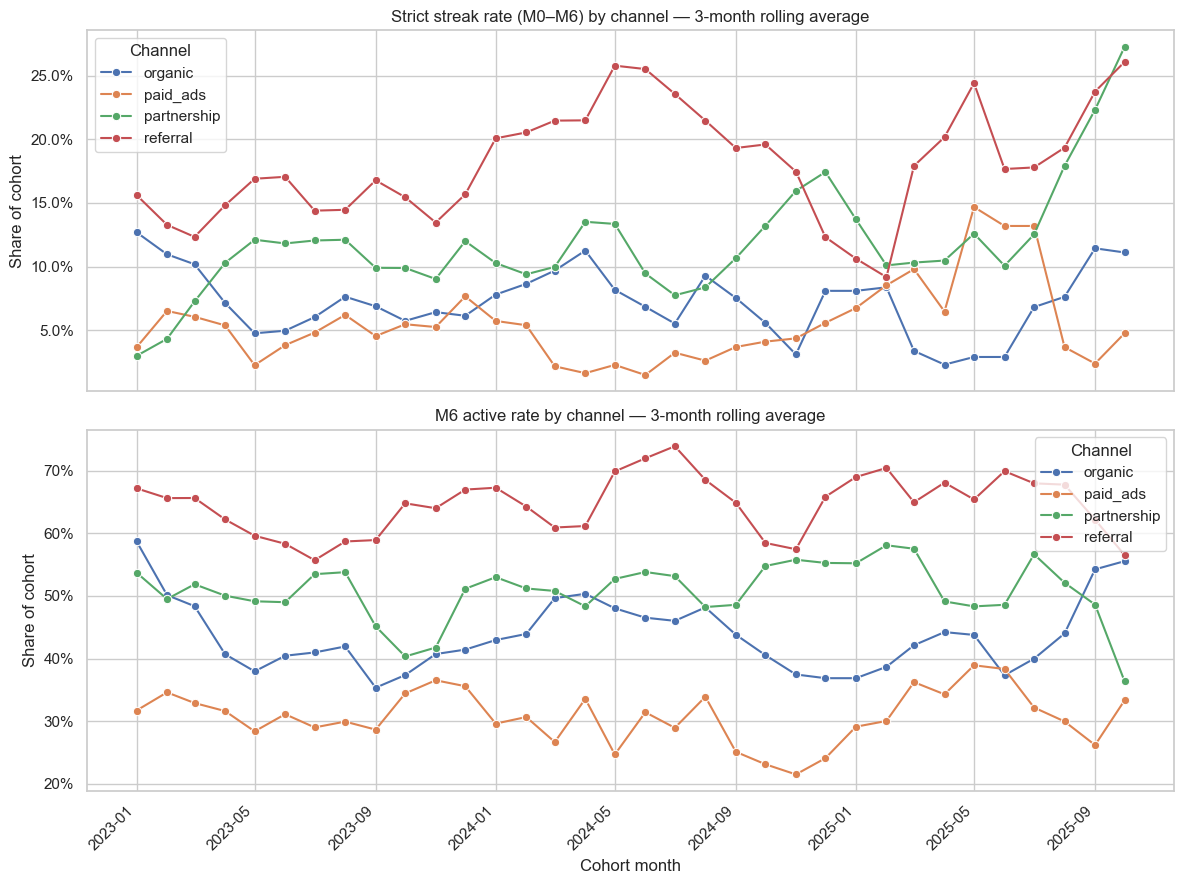

In [ ]:

# Rolling average of channel cohort rates (reduces month-to-month noise)
ROLLING_MONTHS = 3

smooth_ch = plot_ch.sort_values(["acquisition_channel", "cohort_month"]).copy()
smooth_ch["strict_streak_m6_roll"] = smooth_ch.groupby("acquisition_channel")[
    "strict_streak_m6_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())
smooth_ch["m6_active_roll"] = smooth_ch.groupby("acquisition_channel")[
    "m6_active_rate"
].transform(lambda s: s.rolling(ROLLING_MONTHS, min_periods=1).mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="strict_streak_m6_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax1,
)
ax1.set_title(
    f"Strict streak rate (M0–M6) by channel — {ROLLING_MONTHS}-month rolling average"
)
ax1.set_ylabel("Share of cohort")
ax1.set_xlabel("")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(title="Channel", loc="best")

sns.lineplot(
    data=smooth_ch,
    x="cohort_month",
    y="m6_active_roll",
    hue="acquisition_channel",
    marker="o",
    ax=ax2,
)
ax2.set_title(f"M6 active rate by channel — {ROLLING_MONTHS}-month rolling average")
ax2.set_ylabel("Share of cohort")
ax2.set_xlabel("Cohort month")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(title="Channel", loc="best")

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

fig.tight_layout()
plt.show()


**Chart read (3-month rolling average, by `acquisition_channel`):** Top panel = **strict streak (M0–M6)**—share of each cohort that stayed active **every** month through M6. Bottom panel = **M6 active rate**—share active in month 6 **whether or not** they were active in between. Same cohort axis, so you can compare **consistency** vs **late survival** side by side.

**Pattern:** **Referral** tends to lead on **both** charts (strong M6 and stronger streaks)—a good default benchmark for “healthy” acquisition. **Paid_ads** is typically the **weakest** on both metrics, so aggregate retention is often dragged by paid mix. **Organic** often shows a **mid-window dip** with **recovery** in later cohorts—worth validating against product/market calendar, not only “quality drift.” **Partnership** can show **divergence**: streak and M6 do not always move together—if streak rises while M6 falls (or vice versa), the cohort may be **splitting** into a small highly engaged group vs a broader churning base.

**Actionable insight:** (1) **Referral:** protect and scale what works—incentive design, referral UX, and partner comms—since it anchors the **M6 floor** and full streak behavior. (2) **Paid_ads:** run a **structured audit** (campaign/creative/audience/geo) and tie each line item to **M6 and streak**; tighten or pause spend where downstream quality does not clear internal **minimum M6-rate** thresholds. (3) **Partnership:** when streak and M6 disagree, investigate **cohort composition** (B2B vs consumer, promo vs organic signups) and **partner-specific** contracts rather than a single blended KPI. (4) **Organic:** treat recovery as **hypothesis-driven** (SEO, app store, brand)—confirm with segment dashboards before shifting budget. (5) **Governance:** set **channel-level** M6/streak targets and review **mix** monthly so overall charts do not hide a deteriorating paid or partnership line.



<a id="notebook2-closing"></a>

## Notebook summary — business questions & what comes next

[↑ Back to summary](#summary)

### Business questions answered (this notebook)

**Q2 — Which acquisition month produces the most retained customers?**  
**Quality** (highest **M6 active rate**) and **volume** (most **eligible users retained at M6**) often highlight **different** cohort months: early periods can dominate **volume** because cohorts are larger and more users have reached M6; a later month can still win on **rate**. Always read rankings next to **eligible N**—small denominators inflate percentages.

**Q3 — At what month do most customers disengage?**  
On the **aggregate tenure curve** (M6-eligible cohorts), activity is **lowest at M0**, then **jumps by M1**—consistent with **delayed first use** (onboarding lag, funding, or first spend not falling in the signup month), not necessarily “bad” signups. After M1, the **steepest marginal drop** is **M2→M3** (largest step-down in “share active” between consecutive tenure months). **Prioritize re-engagement and habit-building in the M2–M3 window**; pair with **faster time-to-first-value** so more users register activity in M0–M1 if that is a strategic goal.

**Q4 — Are recent cohorts healthier than older ones?**  
**Not something we can call from the aggregate cohort-month lines alone:** the series is **volatile**, **eligible denominators shrink** toward the end of the window, and **M6** is **undefined or thin** for the newest cohorts (cold-start). So a flat or noisy **overall** chart does **not** prove stability—it often **masks mix and sample-size effects**. **Segment** (e.g. by **`acquisition_channel`**) and add **uncertainty** (bands or minimum-N filters) before claiming “recent vs old.” Separately, **track acquisition volume**—a downward trend in new users is a **scale** story that should be analyzed alongside retention.

**Q5 — Which acquisition channel brings the highest quality customers?**  
On the **rolling channel charts** (strict streak **M0–M6** and **M6 active rate**), **Referral** is typically the **strongest** benchmark on both **consistency** and **M6 survival**. **Paid_ads** is typically the **weakest**—treat it as a **quality-and-targeting** problem, not only a budget problem: audit campaigns against **channel-level M6/streak floors**. **Partnership** and **Organic** can **diverge** between the two panels (e.g. streak vs M6 moving differently)—investigate **partner mix** and **organic sources** before reallocating spend. **Governance:** set per-channel targets and review **mix** so the blended chart does not hide a weak channel.

---

**Where the pipeline goes next**

| Next step | Notebook | How it builds on this work |
|-----------|----------|------------------------------|
| Behavioral segments | **Notebook 3** — RFM & clustering | Use monthly **recency / frequency**-style inputs and transaction totals to build **RFM** scores and clusters. |
| Economics | **Notebook 4** — Unit economics | Join **acquisition** fields with **revenue / cost** aggregates for **LTV**, **CAC**, payback. |
| Churn modeling | **Notebook 5** — Logistic regression | Combine **cohort**, **RFM**, and **engagement** features for churn labels and a **probability** model. |


---
